In [ ]:
!apt-get update
!apt-get install -y tshark
!pip install scikit-learn pandas numpy seaborn matplotlib pyshark

Get:1 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Hit:3 https://cli.github.com/packages stable InRelease
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:5 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:10 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [3,844 kB]
Get:11 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,959 kB]
Get:12 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1,310 kB]
Get:13 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [9,977 kB]
Get:14 http://archive.ubu

In [ ]:
import pyshark
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from tqdm import tqdm
import warnings
import asyncio
import nest_asyncio

warnings.filterwarnings("ignore")

asyncio.set_event_loop_policy(asyncio.DefaultEventLoopPolicy())
nest_asyncio.apply()

PCAP_FILES = [
    "capture_loss0.pcap",
    "capture_loss10.pcap",
    "capture_loss15.pcap",
    "capture_loss5.pcap",
    "capture_loss20.pcap"
]

OUTPUT_CSV = "features_selected.csv"
TOP_K = 10
PCA_COMPONENTS = 5


def parse_pcap(pcap_file):
    print(f"\n[*] Parsing {pcap_file} ...")
    cap = pyshark.FileCapture(pcap_file, display_filter="tcp")

    def to_int(val):
        try:
            return int(val)
        except:
            return 1 if str(val).strip().lower() == "true" else 0

    records = []

    for pkt in tqdm(cap, desc=f"Packets ({pcap_file})", unit="pkt"):
        try:
            tcp = pkt.tcp
            ip = pkt.ip

            record = {
                "ip_ttl": int(ip.ttl),
                "ip_len": int(ip.len),
                "ip_proto": int(ip.proto),

                "tcp_srcport": int(tcp.srcport),
                "tcp_dstport": int(tcp.dstport),
                "tcp_seq": int(tcp.seq),
                "tcp_ack": int(tcp.ack),
                "tcp_len": int(tcp.len),
                "tcp_window_size": int(tcp.window_size_value),
                "tcp_hdr_len": int(tcp.hdr_len),

                "flag_syn": to_int(tcp.flags_syn),
                "flag_ack": to_int(tcp.flags_ack),
                "flag_fin": to_int(tcp.flags_fin),
                "flag_rst": to_int(tcp.flags_reset),
                "flag_push": to_int(tcp.flags_push),
                "flag_urg": to_int(tcp.flags_urg),

                "frame_time_delta": float(pkt.frame_info.time_delta),
                "frame_time_epoch": float(pkt.frame_info.time_epoch),

                # Label
                "packet_loss": 1 if hasattr(tcp, "analysis_retransmission") else 0,
            }

            records.append(record)

        except AttributeError:
            continue

    cap.close()

    df = pd.DataFrame(records)

    if df.empty:
        print(f"[!] No TCP packets found in {pcap_file}")
        return df

    df["frame_time_epoch"] = df["frame_time_epoch"] - df["frame_time_epoch"].min()

    print(f"[+] {pcap_file}: {len(df)} packets | Loss: {df['packet_loss'].sum()}")

    return df


def parse_multiple_pcaps(pcap_files):
    all_dfs = []

    for i, file in enumerate(pcap_files):
        df = parse_pcap(file)

        if not df.empty:
            df["file_id"] = i
            df["source_file"] = file
            all_dfs.append(df)

    if not all_dfs:
        raise ValueError("❌ No valid data extracted from PCAP files.")

    combined_df = pd.concat(all_dfs, ignore_index=True)

    print("\n[+] COMBINED DATASET SUMMARY")
    print(f"Total packets : {len(combined_df)}")
    print(f"Columns       : {len(combined_df.columns)}")
    print(f"Loss distribution:\n{combined_df['packet_loss'].value_counts()}")

    return combined_df


def engineer_features(df):
    df = df.sort_values(["file_id", "frame_time_epoch"]).reset_index(drop=True)

    steps = [
        ("Inter-arrival time", lambda d: d.groupby("file_id")["frame_time_epoch"].diff().fillna(0)),
        ("Sequence delta", lambda d: d.groupby("file_id")["tcp_seq"].diff().fillna(0)),
        ("ACK delta", lambda d: d.groupby("file_id")["tcp_ack"].diff().fillna(0)),
        ("Rolling mean len", lambda d: d.groupby("file_id")["tcp_len"].rolling(5, min_periods=1).mean().reset_index(level=0, drop=True)),
        ("Rolling std len", lambda d: d.groupby("file_id")["tcp_len"].rolling(5, min_periods=1).std().fillna(0).reset_index(level=0, drop=True)),
        ("Rolling loss rate", lambda d: d.groupby("file_id")["packet_loss"].rolling(10, min_periods=1).mean().reset_index(level=0, drop=True)),
    ]

    col_names = ["iat", "seq_delta", "ack_delta",
                 "rolling_mean_len", "rolling_std_len", "rolling_loss_rate"]

    for (desc, fn), col in tqdm(zip(steps, col_names), total=len(steps),
                               desc="Engineering features", unit="feature"):
        df[col] = fn(df)

    return df


def select_features(df, top_k=TOP_K, n_pca=PCA_COMPONENTS):
    label_col = "packet_loss"
    drop_cols = [label_col, "frame_time_epoch", "source_file", "file_id"]

    X = df.drop(columns=drop_cols, errors="ignore").fillna(0)
    y = df[label_col]

    feature_names = X.columns.tolist()

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # SelectKBest
    selector = SelectKBest(score_func=f_classif, k=min(top_k, len(feature_names)))
    selector.fit(X_scaled, y)
    kbest_scores = pd.Series(selector.scores_, index=feature_names).sort_values(ascending=False)
    kbest_features = set(kbest_scores.head(top_k).index.tolist())

    # Random Forest
    rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(X_scaled, y)
    rf_scores = pd.Series(rf.feature_importances_, index=feature_names).sort_values(ascending=False)
    rf_features = set(rf_scores.head(top_k).index.tolist())

    # PCA
    pca = PCA(n_components=min(n_pca, X_scaled.shape[1]))
    pca.fit(X_scaled)
    explained = pca.explained_variance_ratio_

    loadings = pd.DataFrame(
        pca.components_.T,
        index=feature_names,
        columns=[f"PC{i+1}" for i in range(pca.n_components_)]
    )
    pca_features = set(loadings.abs().max(axis=1).sort_values(ascending=False).head(top_k).index.tolist())

    intersection = kbest_features | rf_features | pca_features
    ordered_intersection = [f for f in feature_names if f in intersection]

    print("\n[+] Feature Selection Results")
    print(f"  KBest ({len(kbest_features)}) : {sorted(kbest_features)}")
    print(f"  RF    ({len(rf_features)}) : {sorted(rf_features)}")
    print(f"  PCA   ({len(pca_features)}) : {sorted(pca_features)}")
    print(f"\n✅ Intersection ({len(intersection)}) : {sorted(intersection)}")
    print("Explained variance:", np.round(explained, 3), "Total:", explained.sum())

    if len(intersection) == 0:
        raise ValueError("❌ Intersection is empty! Try increasing TOP_K.")

    return {
        "kbest_features":    sorted(kbest_features),
        "rf_features":       sorted(rf_features),
        "pca_features":      sorted(pca_features),
        "selected_features": ordered_intersection,
        "feature_names":     feature_names,
        "scaler":            scaler,
    }


def export_csv(df, results, output_path=OUTPUT_CSV):
    selected = results["selected_features"]

    selected = [c for c in selected if c in df.columns]

    print(f"\n[*] Exporting {len(selected)} features...")

    out_df = df[selected].copy()
    out_df["packet_loss"] = df["packet_loss"].values

    out_df.to_csv(output_path, index=False)

    print(f"[+] Saved dataset → {output_path}")


if __name__ == "__main__":
    df = parse_multiple_pcaps(PCAP_FILES)

    df = engineer_features(df)

    results = select_features(df)

    export_csv(df, results)

    print("\n✅ DONE! Multi-PCAP dataset ready for training.")



[*] Parsing capture_loss0.pcap ...


Packets (capture_loss0.pcap): 63907pkt [09:58, 106.80pkt/s]


[+] capture_loss0.pcap: 63907 packets | Loss: 8

[*] Parsing capture_loss10.pcap ...


Packets (capture_loss10.pcap): 3556pkt [00:41, 86.18pkt/s] 


[+] capture_loss10.pcap: 3556 packets | Loss: 304

[*] Parsing capture_loss15.pcap ...


...

[+] capture_loss5.pcap: 22904 packets | Loss: 701

[*] Parsing capture_loss20.pcap ...


Packets (capture_loss20.pcap): 498pkt [00:04, 119.86pkt/s]


[+] capture_loss20.pcap: 498 packets | Loss: 91

[+] COMBINED DATASET SUMMARY
Total packets : 91518
Columns       : 21
Loss distribution:
packet_loss
0    90336
1     1182
Name: count, dtype: int64


Engineering features: 100%|██████████| 6/6 [00:00<00:00, 55.00feature/s]



[+] Feature Selection Results
  KBest (10) : ['flag_ack', 'flag_fin', 'flag_push', 'flag_syn', 'frame_time_delta', 'iat', 'rolling_loss_rate', 'rolling_std_len', 'tcp_ack', 'tcp_dstport']
  RF    (10) : ['ack_delta', 'frame_time_delta', 'iat', 'ip_len', 'rolling_loss_rate', 'rolling_mean_len', 'rolling_std_len', 'seq_delta', 'tcp_seq', 'tcp_srcport']
  PCA   (10) : ['flag_ack', 'flag_rst', 'flag_syn', 'frame_time_delta', 'iat', 'ip_len', 'rolling_loss_rate', 'rolling_std_len', 'tcp_len', 'tcp_window_size']

✅ Intersection (19) : ['ack_delta', 'flag_ack', 'flag_fin', 'flag_push', 'flag_rst', 'flag_syn', 'frame_time_delta', 'iat', 'ip_len', 'rolling_loss_rate', 'rolling_mean_len', 'rolling_std_len', 'seq_delta', 'tcp_ack', 'tcp_dstport', 'tcp_len', 'tcp_seq', 'tcp_srcport', 'tcp_window_size']
Explained variance: [0.391 0.109 0.097 0.089 0.053] Total: 0.7393340563790389

[*] Exporting 19 features...
[+] Saved dataset → features_selected.csv

✅ DONE! Multi-PCAP dataset ready for training.

In [ ]:
out_df = pd.read_csv("features_selected.csv")
print(out_df.head())
print("Class Distribution:")
print(out_df["packet_loss"].value_counts())
print("\nPercentage:")
print(out_df["packet_loss"].value_counts(normalize=True) * 100)

   ip_len  tcp_srcport  tcp_dstport  tcp_seq  tcp_ack  tcp_len  \
0      60        59366         5001        0        0        0   
1      60        59374         5001        0        0        0   
2      60        59390         5001        0        0        0   
3      60        59398         5001        0        0        0   
4      60        59408         5001        0        0        0   

   tcp_window_size  flag_syn  flag_ack  flag_fin  flag_rst  flag_push  \
0            42340         1         0         0         0          0   
1            42340         1         0         0         0          0   
2            42340         1         0         0         0          0   
3            42340         1         0         0         0          0   
4            42340         1         0         0         0          0   

   frame_time_delta           iat  seq_delta  ack_delta  rolling_mean_len  \
0          0.010112  0.000000e+00        0.0        0.0               0.0   
1         

In [ ]:
from sklearn.model_selection import train_test_split

target = "packet_loss"
features = [col for col in out_df.columns if col != target]

X = out_df[features]
y = out_df[target]

X_train_bal, X_test_bal, y_train_bal, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
!pip install imbalanced-learn

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_bal, y_train_bal = smote.fit_resample(X_train_bal, y_train_bal)

print("After SMOTE:")
print(pd.Series(y_train_bal).value_counts())

After SMOTE:
packet_loss
0    72268
1    72268
Name: count, dtype: int64


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_bal_scaled = scaler.fit_transform(X_train_bal)

X_test_scaled = scaler.transform(X_test_bal)

In [ ]:
pca = PCA(n_components=4)
X_train_pca = pca.fit_transform(X_train_bal_scaled)
X_test_pca = pca.transform(X_test_scaled)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.decomposition import PCA

pca = PCA(n_components=4)

X_train_pca = pca.fit_transform(X_train_bal_scaled)
X_test_pca = pca.transform(X_test_scaled)

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_pca, y_train_bal)

log_pred = log_model.predict(X_test_pca)

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, log_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, log_pred))

Logistic Regression Accuracy: 0.9130244755244755

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.91      0.95     18068
           1       0.12      0.88      0.21       236

    accuracy                           0.91     18304
   macro avg       0.56      0.90      0.58     18304
weighted avg       0.99      0.91      0.94     18304



📊 Logistic Regression Performance
-----------------------------------
Accuracy  : 0.9130
Precision : 0.1174
Recall    : 0.8814
F1 Score  : 0.2072

📄 Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.91      0.95     18068
           1       0.12      0.88      0.21       236

    accuracy                           0.91     18304
   macro avg       0.56      0.90      0.58     18304
weighted avg       0.99      0.91      0.94     18304

🧩 Confusion Matrix:

[[16504  1564]
 [   28   208]]


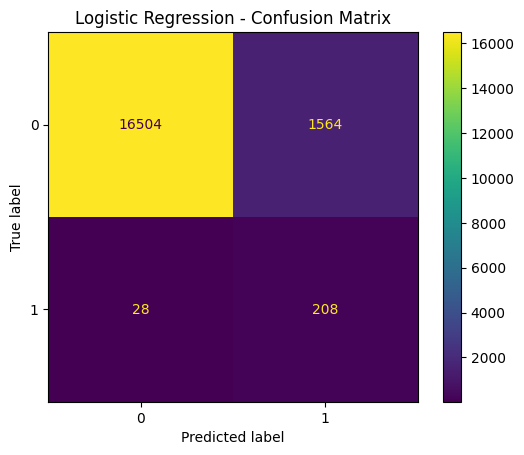

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=4)

X_train_pca = pca.fit_transform(X_train_bal_scaled)
X_test_pca = pca.transform(X_test_scaled)

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_pca, y_train_bal)

log_pred = log_model.predict(X_test_pca)

accuracy  = accuracy_score(y_test, log_pred)
precision = precision_score(y_test, log_pred)
recall    = recall_score(y_test, log_pred)
f1        = f1_score(y_test, log_pred)

print("📊 Logistic Regression Performance")
print("-----------------------------------")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

print("\n📄 Classification Report:\n")
print(classification_report(y_test, log_pred))

cm = confusion_matrix(y_test, log_pred)

print("🧩 Confusion Matrix:\n")
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.decomposition import PCA

pca = PCA(n_components=4)

X_train_pca = pca.fit_transform(X_train_bal_scaled)
X_test_pca = pca.transform(X_test_scaled)

rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf_model.fit(X_train_pca, y_train_bal)

rf_pred = rf_model.predict(X_test_pca)

print("Random Forest Accuracy:",
      accuracy_score(y_test, rf_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.9772727272727273

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     18068
           1       0.33      0.74      0.46       236

    accuracy                           0.98     18304
   macro avg       0.66      0.86      0.72     18304
weighted avg       0.99      0.98      0.98     18304



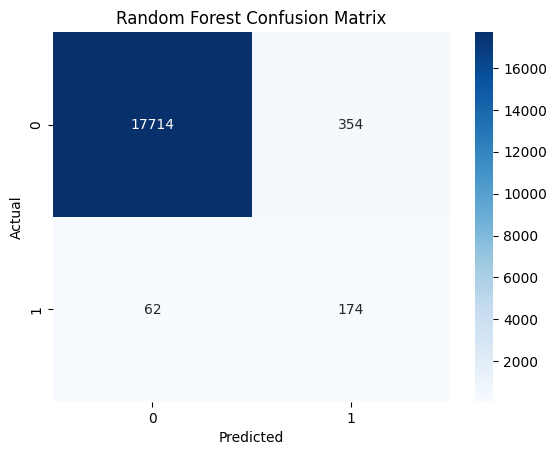

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, rf_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import joblib

scaler = StandardScaler()

X_train_bal_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled = scaler.transform(X_test_bal)

pca = PCA(n_components=4)

X_train_pca = pca.fit_transform(X_train_bal_scaled)
X_test_pca = pca.transform(X_test_scaled)

joblib.dump(scaler, "scaler.pkl")
joblib.dump(pca, "pca.pkl")

['pca.pkl']

SVM Accuracy: 0.9159746503496503

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.92      0.96     18068
           1       0.12      0.92      0.22       236

    accuracy                           0.92     18304
   macro avg       0.56      0.92      0.59     18304
weighted avg       0.99      0.92      0.95     18304



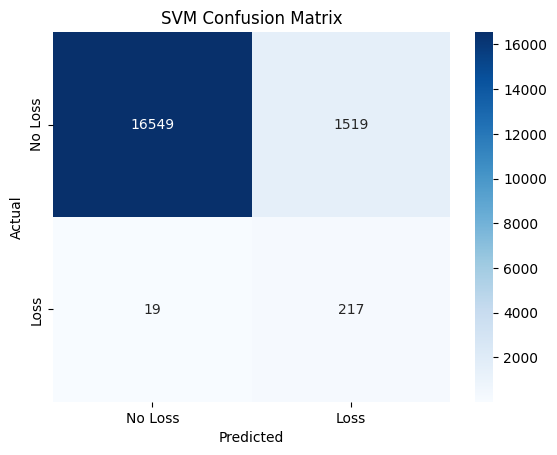

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

svm_model = SVC(kernel='rbf', class_weight='balanced', probability=True)

svm_model.fit(X_train_pca, y_train_bal)

svm_pred = svm_model.predict(X_test_pca)

print("SVM Accuracy:", accuracy_score(y_test, svm_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, svm_pred))

cm = confusion_matrix(y_test, svm_pred)

sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=["No Loss", "Loss"],
            yticklabels=["No Loss", "Loss"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SVM Confusion Matrix")
plt.show()

         SVM Model Performance
  Accuracy  : 0.9160
  Precision : 0.9876
  Recall    : 0.9160
  F1 Score  : 0.9461
  ROC-AUC   : 0.9590

Detailed Classification Report:

              precision    recall  f1-score   support

     No Loss       1.00      0.92      0.96     18068
        Loss       0.12      0.92      0.22       236

    accuracy                           0.92     18304
   macro avg       0.56      0.92      0.59     18304
weighted avg       0.99      0.92      0.95     18304



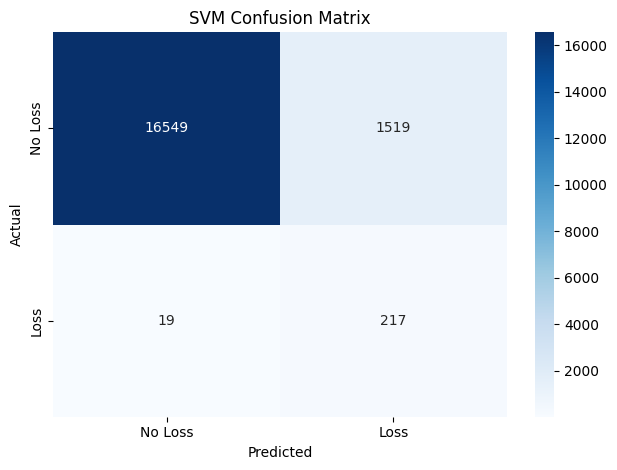

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, precision_score,
                             recall_score, f1_score, roc_auc_score)
import seaborn as sns
import matplotlib.pyplot as plt

svm_model = SVC(kernel='rbf', class_weight='balanced', probability=True)
svm_model.fit(X_train_pca, y_train_bal)

svm_pred = svm_model.predict(X_test_pca)
svm_prob = svm_model.predict_proba(X_test_pca)[:, 1]

# ── Metrics ──────────────────────────────────────────────────────────────────
accuracy  = accuracy_score(y_test, svm_pred)
precision = precision_score(y_test, svm_pred, average='weighted')
recall    = recall_score(y_test, svm_pred, average='weighted')
f1        = f1_score(y_test, svm_pred, average='weighted')
roc_auc   = roc_auc_score(y_test, svm_prob)

print("=" * 40)
print("         SVM Model Performance")
print("=" * 40)
print(f"  Accuracy  : {accuracy:.4f}")
print(f"  Precision : {precision:.4f}")
print(f"  Recall    : {recall:.4f}")
print(f"  F1 Score  : {f1:.4f}")
print(f"  ROC-AUC   : {roc_auc:.4f}")
print("=" * 40)

print("\nDetailed Classification Report:\n")
print(classification_report(y_test, svm_pred, target_names=["No Loss", "Loss"]))

# ── Confusion Matrix ─────────────────────────────────────────────────────────
cm = confusion_matrix(y_test, svm_pred)

sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=["No Loss", "Loss"],
            yticklabels=["No Loss", "Loss"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SVM Confusion Matrix")
plt.tight_layout()
plt.show()

In [ ]:
!pip install xgboost

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb_model.fit(X_train_pca, y_train_bal)

xgb_pred = xgb_model.predict(X_test_pca)

print("XGBoost Accuracy:", accuracy_score(y_test, xgb_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, xgb_pred))

XGBoost Accuracy: 0.9659637237762237

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.97      0.98     18068
           1       0.25      0.85      0.39       236

    accuracy                           0.97     18304
   macro avg       0.63      0.91      0.69     18304
weighted avg       0.99      0.97      0.97     18304



       XGBoost Model Performance
  Accuracy  : 0.9660
  Precision : 0.9884
  Recall    : 0.9660
  F1 Score  : 0.9749
  ROC-AUC   : 0.9790

Detailed Classification Report:

              precision    recall  f1-score   support

     No Loss       1.00      0.97      0.98     18068
        Loss       0.25      0.85      0.39       236

    accuracy                           0.97     18304
   macro avg       0.63      0.91      0.69     18304
weighted avg       0.99      0.97      0.97     18304



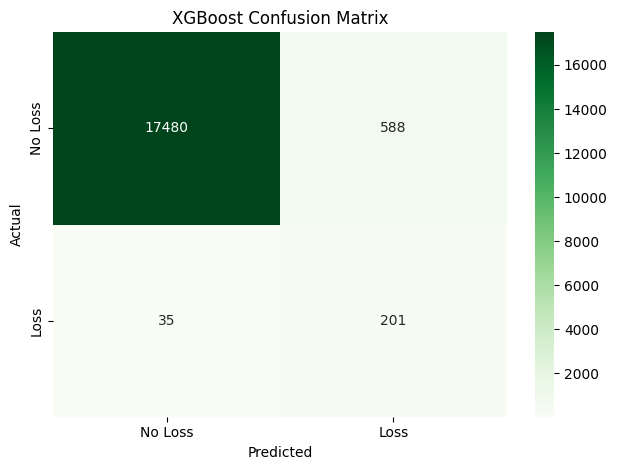

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, precision_score,
                             recall_score, f1_score, roc_auc_score)
import seaborn as sns
import matplotlib.pyplot as plt

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb_model.fit(X_train_pca, y_train_bal)

xgb_pred = xgb_model.predict(X_test_pca)
xgb_prob = xgb_model.predict_proba(X_test_pca)[:, 1]

# ── Metrics ──────────────────────────────────────────────────────────────────
accuracy  = accuracy_score(y_test, xgb_pred)
precision = precision_score(y_test, xgb_pred, average='weighted')
recall    = recall_score(y_test, xgb_pred, average='weighted')
f1        = f1_score(y_test, xgb_pred, average='weighted')
roc_auc   = roc_auc_score(y_test, xgb_prob)

print("=" * 40)
print("       XGBoost Model Performance")
print("=" * 40)
print(f"  Accuracy  : {accuracy:.4f}")
print(f"  Precision : {precision:.4f}")
print(f"  Recall    : {recall:.4f}")
print(f"  F1 Score  : {f1:.4f}")
print(f"  ROC-AUC   : {roc_auc:.4f}")
print("=" * 40)

print("\nDetailed Classification Report:\n")
print(classification_report(y_test, xgb_pred, target_names=["No Loss", "Loss"]))

# ── Confusion Matrix ─────────────────────────────────────────────────────────
cm = confusion_matrix(y_test, xgb_pred)

sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Greens",
            xticklabels=["No Loss", "Loss"],
            yticklabels=["No Loss", "Loss"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost Confusion Matrix")
plt.tight_layout()
plt.show()

Epoch 1/50
452/452 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9029 - loss: 0.2585 - val_accuracy: 0.9548 - val_loss: 0.2037
Epoch 2/50
452/452 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9403 - loss: 0.1726 - val_accuracy: 0.9685 - val_loss: 0.1594
Epoch 3/50
452/452 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9476 - loss: 0.1516 - val_accuracy: 0.9727 - val_loss: 0.1394
Epoch 4/50
452/452 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9507 - loss: 0.1430 - val_accuracy: 0.9743 - val_loss: 0.1290
Epoch 5/50
452/452 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9519 - loss: 0.1381 - val_accuracy: 0.9767 - val_loss: 0.1236
Epoch 6/50
452/452 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9535 - loss: 0.1336 - val_accuracy: 0.9734 - val_loss: 0.1197
Epoch 7/50
452/452 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9547 - loss: 0.1301 - val_accuracy: 0.9724 - val_loss: 0.1261
Epoch 8/50
452/452 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9562 - loss: 0.1256 - val_accuracy: 0.

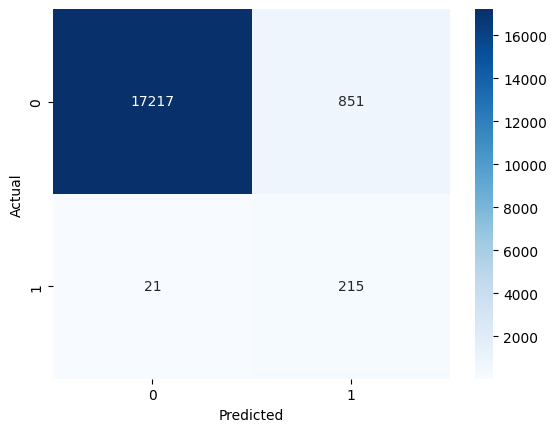

Neural Network model saved successfully.


In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

model = tf.keras.Sequential([

    tf.keras.layers.Dense(64, activation='relu', input_shape=(X_train_pca.shape[1],)),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(16, activation='relu'),

    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train_pca,
    y_train_bal,
    epochs=50,
    batch_size=256,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

test_loss, test_accuracy = model.evaluate(X_test_pca, y_test)

print("Neural Network Test Accuracy:", test_accuracy)

y_pred_prob = model.predict(X_test_pca)
y_pred = (y_pred_prob > 0.5).astype(int)

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

model.save("neural_network_model.h5")

print("Neural Network model saved successfully.")

Epoch 1/50
452/452 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9149 - loss: 0.2392 - val_accuracy: 0.9564 - val_loss: 0.1902
Epoch 2/50
452/452 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9400 - loss: 0.1716 - val_accuracy: 0.9708 - val_loss: 0.1589
Epoch 3/50
452/452 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9480 - loss: 0.1510 - val_accuracy: 0.9682 - val_loss: 0.1515
Epoch 4/50
452/452 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9510 - loss: 0.1427 - val_accuracy: 0.9753 - val_loss: 0.1201
Epoch 5/50
452/452 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9528 - loss: 0.1372 - val_accuracy: 0.9787 - val_loss: 0.1320
Epoch 6/50
452/452 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9534 - loss: 0.1337 - val_accuracy: 0.9763 - val_loss: 0.1073
Epoch 7/50
452/452 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9544 - loss: 0.1304 - val_accuracy: 0.9699 - val_loss: 0.1259
Epoch 8/50
452/452 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9556 - loss: 0.1262 - val_accuracy: 0.

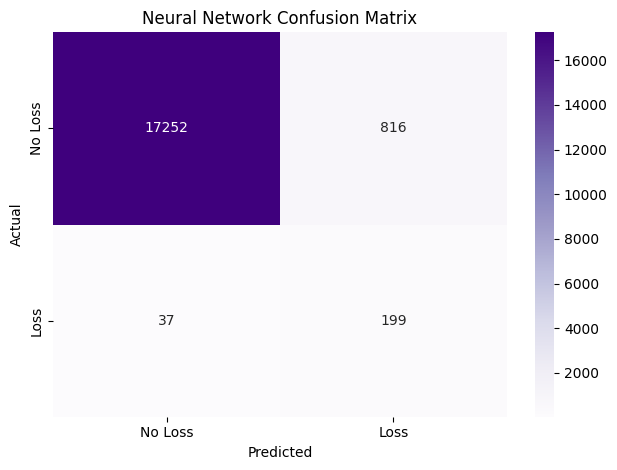

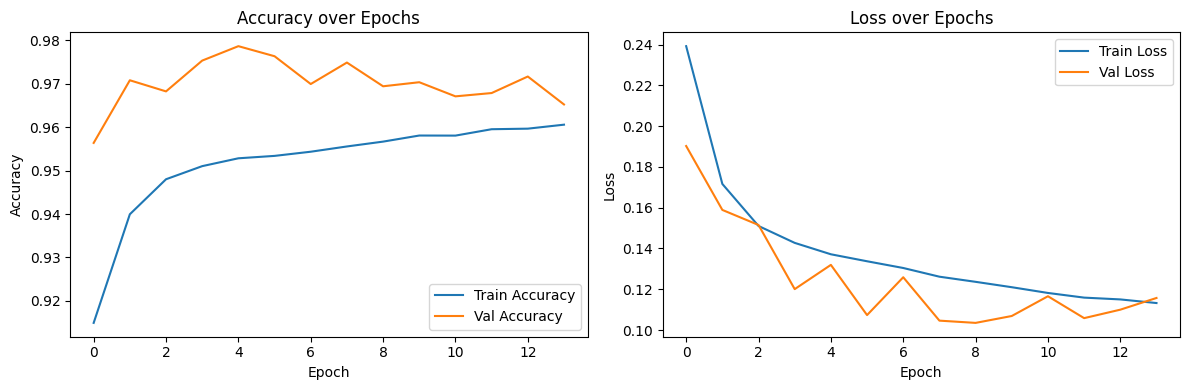

Neural Network model saved successfully.


In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf

from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score)
import seaborn as sns
import matplotlib.pyplot as plt

model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(X_train_pca.shape[1],)),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(16, activation='relu'),

    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train_pca,
    y_train_bal,
    epochs=50,
    batch_size=256,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

# ── Evaluation ───────────────────────────────────────────────────────────────
test_loss, test_accuracy = model.evaluate(X_test_pca, y_test, verbose=0)

y_pred_prob = model.predict(X_test_pca).flatten()
y_pred      = (y_pred_prob > 0.5).astype(int)

# ── Metrics ──────────────────────────────────────────────────────────────────
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall    = recall_score(y_test, y_pred, average='weighted')
f1        = f1_score(y_test, y_pred, average='weighted')
roc_auc   = roc_auc_score(y_test, y_pred_prob)

print("=" * 40)
print("   Neural Network Model Performance")
print("=" * 40)
print(f"  Accuracy  : {accuracy:.4f}")
print(f"  Precision : {precision:.4f}")
print(f"  Recall    : {recall:.4f}")
print(f"  F1 Score  : {f1:.4f}")
print(f"  ROC-AUC   : {roc_auc:.4f}")
print(f"  Test Loss : {test_loss:.4f}")
print("=" * 40)

print("\nDetailed Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=["No Loss", "Loss"]))

# ── Confusion Matrix ─────────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Purples",
            xticklabels=["No Loss", "Loss"],
            yticklabels=["No Loss", "Loss"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Neural Network Confusion Matrix")
plt.tight_layout()
plt.show()

# ── Training History Plot ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'],     label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'],     label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

model.save("neural_network_model.h5")
print("Neural Network model saved successfully.")

In [ ]:
import joblib

joblib.dump(log_model, "logistic_model.pkl")
joblib.dump(rf_model, "random_forest_model.pkl")
joblib.dump(svm_model, "svm_model.pkl")
joblib.dump(xgb_model, "xgboost_model.pkl")

joblib.dump(scaler, "scaler.pkl")

print("All models saved successfully.")

All models saved successfully.


In [ ]:
import joblib
import tensorflow as tf

log_model = joblib.load("logistic_model.pkl")
rf_model = joblib.load("random_forest_model.pkl")
svm_model = joblib.load("svm_model.pkl")
xgb_model = joblib.load("xgboost_model.pkl")

scaler = joblib.load("scaler.pkl")
pca = joblib.load("pca.pkl")

try:
    nn_model = tf.keras.models.load_model(
        "neural_network_model.h5",
        compile=False
    )
    print("✅ Neural Network loaded")
except Exception as e:
    print("⚠️ Neural Network failed to load:", e)
    nn_model = None

print("✅ All models and preprocessing objects loaded successfully.")

✅ Neural Network loaded
✅ All models and preprocessing objects loaded successfully.


In [ ]:
new_packet = [[
    # Intersection of KBest + RF + PCA selected features (19 total)
    # ['ack_delta', 'flag_ack', 'flag_fin', 'flag_push', 'flag_rst', 'flag_syn',
    #  'frame_time_delta', 'iat', 'ip_len', 'rolling_loss_rate', 'rolling_mean_len',
    #  'rolling_std_len', 'seq_delta', 'tcp_ack', 'tcp_dstport', 'tcp_len',
    #  'tcp_seq', 'tcp_srcport', 'tcp_window_size']

    0,                  # ack_delta        (ACK sequence delta)
    1,                  # flag_ack         (ACK flag set)
    0,                  # flag_fin         (FIN flag not set)
    1,                  # flag_push        (PUSH flag set)
    0,                  # flag_rst         (RST flag not set)
    0,                  # flag_syn         (SYN flag not set)
    0.002,              # frame_time_delta (low delay, normal traffic)
    0.002,              # iat              (inter-arrival time)
    100,                # ip_len           (typical small packet size in bytes)
    0.0,                # rolling_loss_rate(no packet loss)
    100.0,              # rolling_mean_len (average packet length)
    0.0,                # rolling_std_len  (stable packet sizes)
    100,                # seq_delta        (TCP sequence delta)
    1000,               # tcp_ack          (ACK number)
    443,                # tcp_dstport      (HTTPS destination port)
    50,                 # tcp_len          (TCP payload length)
    5000,               # tcp_seq          (TCP sequence number)
    54321,              # tcp_srcport      (ephemeral source port)
    65535,              # tcp_window_size  (full receive window)
]]

In [ ]:
new_scaled = scaler.transform(new_packet)

new_pca = pca.transform(new_scaled)

svm_prediction = svm_model.predict(new_pca)
log_prediction = log_model.predict(new_pca)

print("SVM:", "Packet Lost" if svm_prediction[0] == 1 else "No Loss")
print("Logistic:", "Packet Lost" if log_prediction[0] == 1 else "No Loss")

SVM: No Loss
Logistic: Packet Lost


In [ ]:
new_scaled = scaler.transform(new_packet)

new_pca = pca.transform(new_scaled)

rf_prediction = rf_model.predict(new_pca)
xgb_prediction = xgb_model.predict(new_pca)

print("Random Forest:", "Packet Lost" if rf_prediction[0] == 1 else "No Loss")
print("XGBoost:", "Packet Lost" if xgb_prediction[0] == 1 else "No Loss")

Random Forest: Packet Lost
XGBoost: No Loss


In [ ]:
import joblib

joblib.dump(log_model, "logistic_model.pkl")
joblib.dump(rf_model, "random_forest_model.pkl")
joblib.dump(svm_model, "svm_model.pkl")
joblib.dump(xgb_model, "xgboost_model.pkl")

joblib.dump(scaler, "scaler.pkl")

print("All models saved successfully.")

All models saved successfully.


In [ ]:
from google.colab import files

files.download("logistic_model.pkl")
files.download("random_forest_model.pkl")
files.download("svm_model.pkl")
files.download("xgboost_model.pkl")
files.download("neural_network_model.h5")
files.download("scaler.pkl")
files.download("pca.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import numpy as np

SEQUENCE_LENGTH = 10

def create_sequences(X, y, seq_len=10):
    X_seq, y_seq = [], []

    for i in range(len(X) - seq_len):
        X_seq.append(X[i:i+seq_len])
        y_seq.append(y[i+seq_len])

    return np.array(X_seq), np.array(y_seq)


# Use PCA output (IMPORTANT)
X_train_seq, y_train_seq = create_sequences(X_train_pca, y_train_bal.values, SEQUENCE_LENGTH)
X_test_seq, y_test_seq   = create_sequences(X_test_pca, y_test.values, SEQUENCE_LENGTH)

print("Train shape:", X_train_seq.shape)
print("Test shape :", X_test_seq.shape)


Train shape: (144526, 10, 4)
Test shape : (18294, 10, 4)


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

lstm_model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(SEQUENCE_LENGTH, X_train_seq.shape[2])),
    Dropout(0.3),

    LSTM(32),
    Dropout(0.3),

    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

lstm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 10, 64)         │        17,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,625 (119.63 KB)

 Trainable params: 30,625 (119.63 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = lstm_model.fit(
    X_train_seq, y_train_seq,
    epochs=30,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stop]
)

loss, acc = lstm_model.evaluate(X_test_seq, y_test_seq)
print("LSTM Accuracy:", acc)

Epoch 1/30
904/904 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9887 - loss: 0.0595 - val_accuracy: 1.0000 - val_loss: 1.2739e-04
Epoch 2/30
904/904 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9917 - loss: 0.0453 - val_accuracy: 1.0000 - val_loss: 1.5532e-05
Epoch 3/30
904/904 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9918 - loss: 0.0454 - val_accuracy: 1.0000 - val_loss: 1.7952e-05
Epoch 4/30
904/904 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9917 - loss: 0.0450 - val_accuracy: 1.0000 - val_loss: 1.1642e-05
Epoch 5/30
904/904 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.9918 - loss: 0.0448 - val_accuracy: 1.0000 - val_loss: 3.7200e-06
Epoch 6/30
904/904 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.9918 - loss: 0.0451 - val_accuracy: 1.0000 - val_loss: 1.1741e-05
Epoch 7/30
904/904 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9918 - loss: 0.0448 - val_accuracy: 1.0000 - val_loss: 1.9086e-06
Epoch 8/30
904/904 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.9918 - l

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 10, 64)         │        17,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,625 (119.63 KB)

 Trainable params: 30,625 (119.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
904/904 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.9875 - loss: 0.0635 - val_accuracy: 0.9999 - val_loss: 4.8203e-04
Epoch 2/30
904/904 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9917 - loss: 0.0458 - val_accuracy: 1.0000 - val_loss: 4.8903e-05
Epoch 3/30
904/904 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9917 - loss: 0.0453 - val_accuracy: 1.0000 - val_loss: 1.4970e-06
Epoch 4/30
904/904 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9917 - loss: 0.0451 - val_accuracy: 1.0000 - val_loss: 2.8660e-05
Epoch 5/30
904/904 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9918 - loss: 0.0452 - val_accuracy: 1.0000 - val_loss: 9.3443e-07
Epoch 6/30
904/904 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9917 - loss: 0.0447 - val_accuracy: 1.0000 - val_loss: 1.1675e-05
Epoch 7/30
904/904 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9918 - loss: 0.0447 - val_accuracy: 1.0000 - val_loss: 1.1112e-06
Epoch 8/30
904/904 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.9918 - l

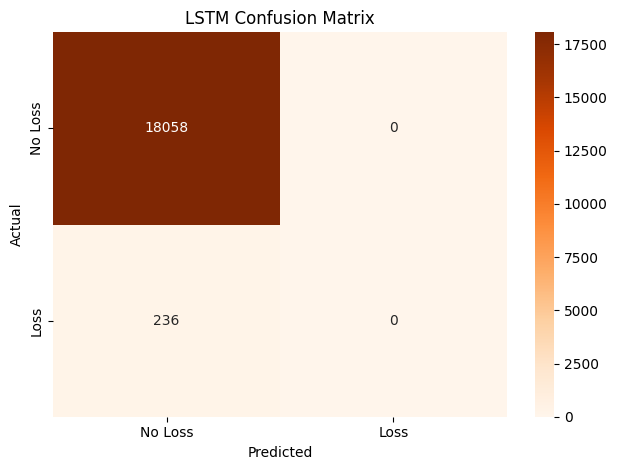

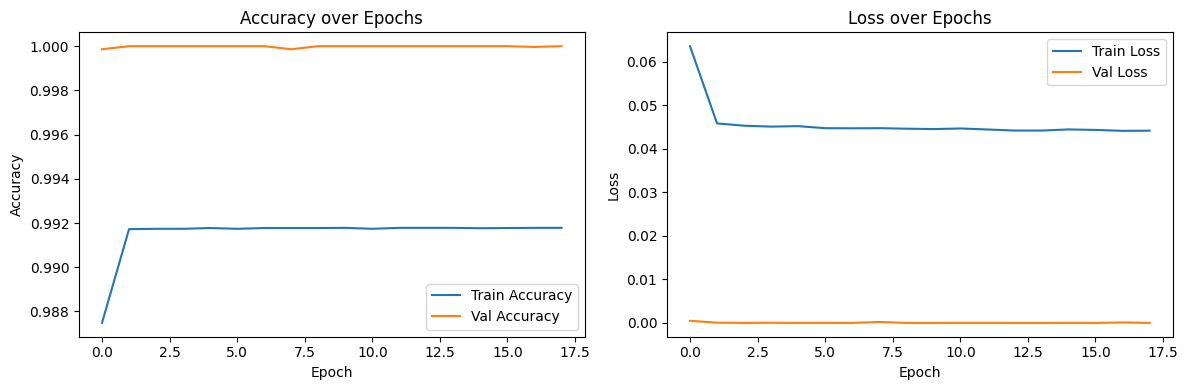

LSTM model saved successfully.


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, precision_score,
                             recall_score, f1_score, roc_auc_score)
import seaborn as sns
import matplotlib.pyplot as plt

lstm_model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(SEQUENCE_LENGTH, X_train_seq.shape[2])),
    Dropout(0.3),

    LSTM(32),
    Dropout(0.3),

    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

lstm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

lstm_model.summary()

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = lstm_model.fit(
    X_train_seq, y_train_seq,
    epochs=30,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stop]
)

# ── Evaluation ───────────────────────────────────────────────────────────────
test_loss, test_accuracy = lstm_model.evaluate(X_test_seq, y_test_seq, verbose=0)

y_pred_prob = lstm_model.predict(X_test_seq).flatten()
y_pred      = (y_pred_prob > 0.5).astype(int)

# ── Metrics ──────────────────────────────────────────────────────────────────
accuracy  = accuracy_score(y_test_seq, y_pred)
precision = precision_score(y_test_seq, y_pred, average='weighted')
recall    = recall_score(y_test_seq, y_pred, average='weighted')
f1        = f1_score(y_test_seq, y_pred, average='weighted')
roc_auc   = roc_auc_score(y_test_seq, y_pred_prob)

print("=" * 40)
print("       LSTM Model Performance")
print("=" * 40)
print(f"  Accuracy  : {accuracy:.4f}")
print(f"  Precision : {precision:.4f}")
print(f"  Recall    : {recall:.4f}")
print(f"  F1 Score  : {f1:.4f}")
print(f"  ROC-AUC   : {roc_auc:.4f}")
print(f"  Test Loss : {test_loss:.4f}")
print("=" * 40)

print("\nDetailed Classification Report:\n")
print(classification_report(y_test_seq, y_pred, target_names=["No Loss", "Loss"]))

# ── Confusion Matrix ─────────────────────────────────────────────────────────
cm = confusion_matrix(y_test_seq, y_pred)

sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Oranges",
            xticklabels=["No Loss", "Loss"],
            yticklabels=["No Loss", "Loss"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("LSTM Confusion Matrix")
plt.tight_layout()
plt.show()

# ── Training History Plot ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'],     label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'],     label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

lstm_model.save("lstm_model.h5")
print("LSTM model saved successfully.")

In [ ]:
from tensorflow.keras.layers import GRU

gru_model = Sequential([
    GRU(64, return_sequences=True, input_shape=(SEQUENCE_LENGTH, X_train_seq.shape[2])),
    Dropout(0.3),

    GRU(32),
    Dense(1, activation='sigmoid')
])

gru_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

gru_model.fit(
    X_train_seq, y_train_seq,
    epochs=25,
    batch_size=128,
    validation_split=0.2
)

loss, acc = gru_model.evaluate(X_test_seq, y_test_seq)
print("GRU Accuracy:", acc)

Epoch 1/25
904/904 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.9910 - loss: 0.0512 - val_accuracy: 0.9998 - val_loss: 9.5781e-04
Epoch 2/25
904/904 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9917 - loss: 0.0443 - val_accuracy: 0.9999 - val_loss: 4.1265e-04
Epoch 3/25
904/904 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9918 - loss: 0.0442 - val_accuracy: 1.0000 - val_loss: 1.8729e-04
Epoch 4/25
904/904 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9918 - loss: 0.0441 - val_accuracy: 1.0000 - val_loss: 2.5748e-04
Epoch 5/25
904/904 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9918 - loss: 0.0441 - val_accuracy: 1.0000 - val_loss: 1.3182e-04
Epoch 6/25
904/904 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9918 - loss: 0.0440 - val_accuracy: 1.0000 - val_loss: 1.0768e-04
Epoch 7/25
904/904 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9918 - loss: 0.0440 - val_accuracy: 1.0000 - val_loss: 8.4280e-05
Epoch 8/25
904/904 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9918 - lo

Epoch 1/25
904/904 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.9898 - loss: 0.0534 - val_accuracy: 1.0000 - val_loss: 5.6198e-04
Epoch 2/25
904/904 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9918 - loss: 0.0444 - val_accuracy: 1.0000 - val_loss: 2.7469e-04
Epoch 3/25
904/904 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9918 - loss: 0.0442 - val_accuracy: 1.0000 - val_loss: 2.2163e-04
Epoch 4/25
904/904 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9918 - loss: 0.0441 - val_accuracy: 1.0000 - val_loss: 1.5587e-04
Epoch 5/25
904/904 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9918 - loss: 0.0441 - val_accuracy: 1.0000 - val_loss: 1.3331e-04
Epoch 6/25
904/904 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9918 - loss: 0.0440 - val_accuracy: 1.0000 - val_loss: 1.0980e-04
Epoch 7/25
904/904 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9918 - loss: 0.0440 - val_accuracy: 1.0000 - val_loss: 7.8902e-05
Epoch 8/25
904/904 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.9917 - los

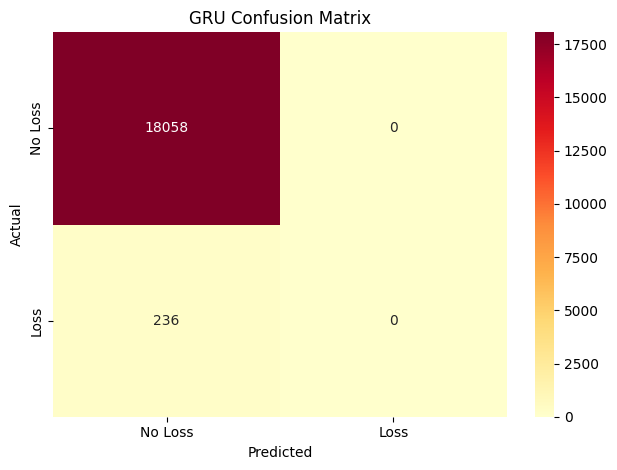

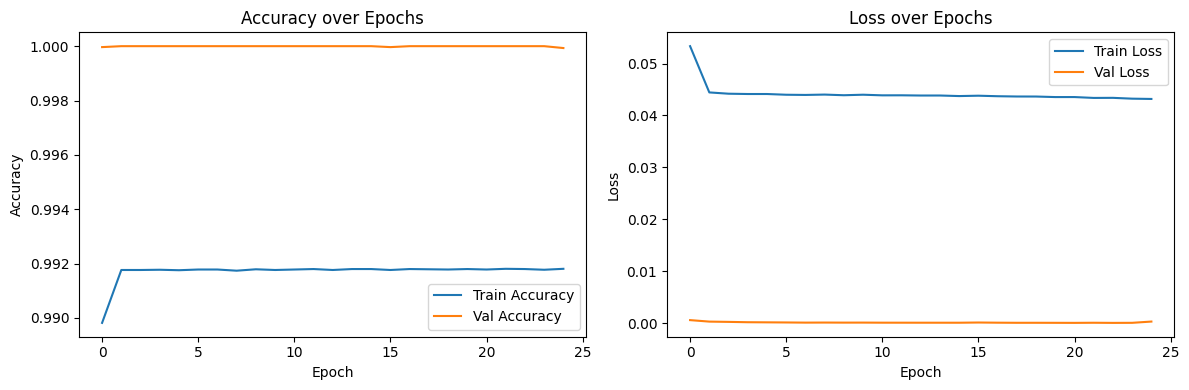

GRU model saved successfully.


In [ ]:
from tensorflow.keras.layers import GRU
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, precision_score,
                             recall_score, f1_score, roc_auc_score)
import seaborn as sns
import matplotlib.pyplot as plt

gru_model = Sequential([
    GRU(64, return_sequences=True, input_shape=(SEQUENCE_LENGTH, X_train_seq.shape[2])),
    Dropout(0.3),

    GRU(32),
    Dense(1, activation='sigmoid')
])

gru_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = gru_model.fit(
    X_train_seq, y_train_seq,
    epochs=25,
    batch_size=128,
    validation_split=0.2
)

# ── Evaluation ───────────────────────────────────────────────────────────────
test_loss, test_accuracy = gru_model.evaluate(X_test_seq, y_test_seq, verbose=0)

y_pred_prob = gru_model.predict(X_test_seq).flatten()
y_pred      = (y_pred_prob > 0.5).astype(int)

# ── Metrics ──────────────────────────────────────────────────────────────────
accuracy  = accuracy_score(y_test_seq, y_pred)
precision = precision_score(y_test_seq, y_pred, average='weighted')
recall    = recall_score(y_test_seq, y_pred, average='weighted')
f1        = f1_score(y_test_seq, y_pred, average='weighted')
roc_auc   = roc_auc_score(y_test_seq, y_pred_prob)

print("=" * 40)
print("        GRU Model Performance")
print("=" * 40)
print(f"  Accuracy  : {accuracy:.4f}")
print(f"  Precision : {precision:.4f}")
print(f"  Recall    : {recall:.4f}")
print(f"  F1 Score  : {f1:.4f}")
print(f"  ROC-AUC   : {roc_auc:.4f}")
print(f"  Test Loss : {test_loss:.4f}")
print("=" * 40)

print("\nDetailed Classification Report:\n")
print(classification_report(y_test_seq, y_pred, target_names=["No Loss", "Loss"]))

# ── Confusion Matrix ─────────────────────────────────────────────────────────
cm = confusion_matrix(y_test_seq, y_pred)

sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="YlOrRd",
            xticklabels=["No Loss", "Loss"],
            yticklabels=["No Loss", "Loss"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("GRU Confusion Matrix")
plt.tight_layout()
plt.show()

# ── Training History Plot ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'],     label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'],     label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

gru_model.save("gru_model.h5")
print("GRU model saved successfully.")

In [ ]:
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten

cnn_model = Sequential([
    Conv1D(64, 3, activation='relu', input_shape=(SEQUENCE_LENGTH, X_train_seq.shape[2])),
    MaxPooling1D(2),

    Conv1D(32, 3, activation='relu'),
    MaxPooling1D(2),

    Flatten(),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

cnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

cnn_model.fit(
    X_train_seq, y_train_seq,
    epochs=25,
    batch_size=128,
    validation_split=0.2
)

loss, acc = cnn_model.evaluate(X_test_seq, y_test_seq)
print("CNN Accuracy:", acc)

Epoch 1/25
904/904 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9875 - loss: 0.0583 - val_accuracy: 1.0000 - val_loss: 3.6082e-04
Epoch 2/25
904/904 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9917 - loss: 0.0453 - val_accuracy: 1.0000 - val_loss: 3.4075e-04
Epoch 3/25
904/904 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9917 - loss: 0.0451 - val_accuracy: 1.0000 - val_loss: 7.8232e-05
Epoch 4/25
904/904 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9917 - loss: 0.0445 - val_accuracy: 1.0000 - val_loss: 3.9111e-05
Epoch 5/25
904/904 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9917 - loss: 0.0443 - val_accuracy: 0.9996 - val_loss: 0.0012
Epoch 6/25
904/904 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9918 - loss: 0.0440 - val_accuracy: 1.0000 - val_loss: 1.6820e-04
Epoch 7/25
904/904 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9917 - loss: 0.0443 - val_accuracy: 0.9998 - val_loss: 6.4938e-04
Epoch 8/25
904/904 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9918 - loss: 0

Epoch 1/25
904/904 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9874 - loss: 0.0609 - val_accuracy: 0.9999 - val_loss: 7.4225e-04
Epoch 2/25
904/904 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9917 - loss: 0.0453 - val_accuracy: 0.9999 - val_loss: 3.5651e-04
Epoch 3/25
904/904 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9917 - loss: 0.0449 - val_accuracy: 0.9992 - val_loss: 0.0020
Epoch 4/25
904/904 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9916 - loss: 0.0448 - val_accuracy: 1.0000 - val_loss: 6.2646e-05
Epoch 5/25
904/904 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9918 - loss: 0.0444 - val_accuracy: 1.0000 - val_loss: 3.2300e-05
Epoch 6/25
904/904 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9917 - loss: 0.0442 - val_accuracy: 0.9999 - val_loss: 2.1507e-04
Epoch 7/25
904/904 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9917 - loss: 0.0442 - val_accuracy: 0.9999 - val_loss: 1.3647e-04
Epoch 8/25
904/904 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9918 - loss: 0

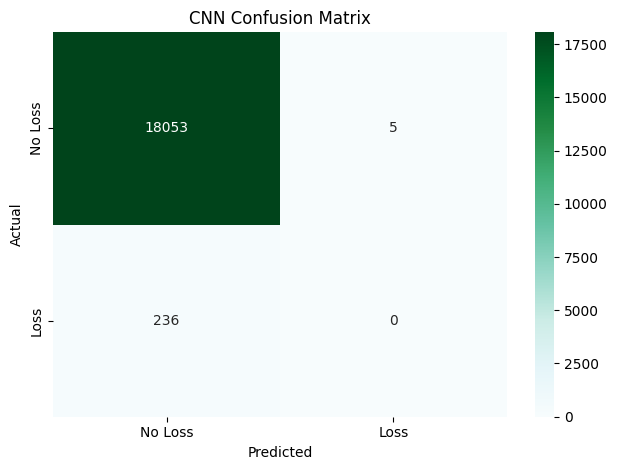

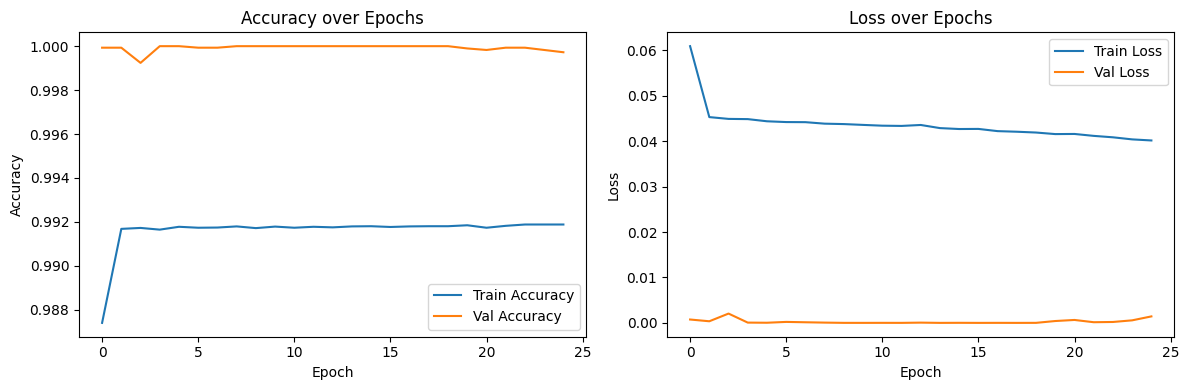

CNN model saved successfully.


In [ ]:
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, precision_score,
                             recall_score, f1_score, roc_auc_score)
import seaborn as sns
import matplotlib.pyplot as plt

cnn_model = Sequential([
    Conv1D(64, 3, activation='relu', input_shape=(SEQUENCE_LENGTH, X_train_seq.shape[2])),
    MaxPooling1D(2),

    Conv1D(32, 3, activation='relu'),
    MaxPooling1D(2),

    Flatten(),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

cnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = cnn_model.fit(
    X_train_seq, y_train_seq,
    epochs=25,
    batch_size=128,
    validation_split=0.2
)

# ── Evaluation ───────────────────────────────────────────────────────────────
test_loss, test_accuracy = cnn_model.evaluate(X_test_seq, y_test_seq, verbose=0)

y_pred_prob = cnn_model.predict(X_test_seq).flatten()
y_pred      = (y_pred_prob > 0.5).astype(int)

# ── Metrics ──────────────────────────────────────────────────────────────────
accuracy  = accuracy_score(y_test_seq, y_pred)
precision = precision_score(y_test_seq, y_pred, average='weighted')
recall    = recall_score(y_test_seq, y_pred, average='weighted')
f1        = f1_score(y_test_seq, y_pred, average='weighted')
roc_auc   = roc_auc_score(y_test_seq, y_pred_prob)

print("=" * 40)
print("       CNN Model Performance")
print("=" * 40)
print(f"  Accuracy  : {accuracy:.4f}")
print(f"  Precision : {precision:.4f}")
print(f"  Recall    : {recall:.4f}")
print(f"  F1 Score  : {f1:.4f}")
print(f"  ROC-AUC   : {roc_auc:.4f}")
print(f"  Test Loss : {test_loss:.4f}")
print("=" * 40)

print("\nDetailed Classification Report:\n")
print(classification_report(y_test_seq, y_pred, target_names=["No Loss", "Loss"]))

# ── Confusion Matrix ─────────────────────────────────────────────────────────
cm = confusion_matrix(y_test_seq, y_pred)

sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="BuGn",
            xticklabels=["No Loss", "Loss"],
            yticklabels=["No Loss", "Loss"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("CNN Confusion Matrix")
plt.tight_layout()
plt.show()

# ── Training History Plot ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'],     label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'],     label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

cnn_model.save("cnn_model.h5")
print("CNN model saved successfully.")

In [ ]:
lstm_model.save("lstm_model.h5")
gru_model.save("gru_model.h5")
cnn_model.save("cnn_model.h5")

print("✅ All sequence models saved")

✅ All sequence models saved


In [ ]:
from google.colab import files

files.download("lstm_model.h5")
files.download("gru_model.h5")
files.download("cnn_model.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

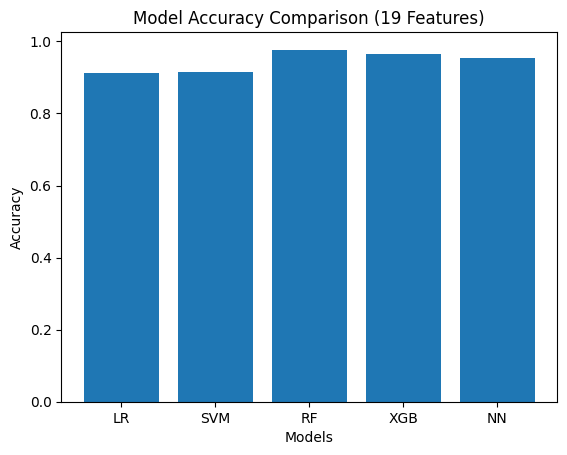

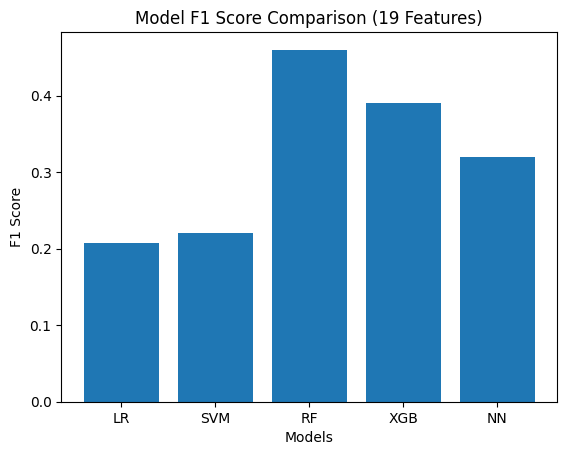

In [ ]:
import matplotlib.pyplot as plt

models = ["LR", "SVM", "RF", "XGB", "NN"]

accuracy = [0.913, 0.916, 0.977, 0.966, 0.953]
f1_scores = [0.207, 0.22, 0.46, 0.39, 0.32]

# Accuracy Plot
plt.figure()
plt.bar(models, accuracy)
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison (19 Features)")
plt.show()

# F1 Score Plot
plt.figure()
plt.bar(models, f1_scores)
plt.xlabel("Models")
plt.ylabel("F1 Score")
plt.title("Model F1 Score Comparison (19 Features)")
plt.show()

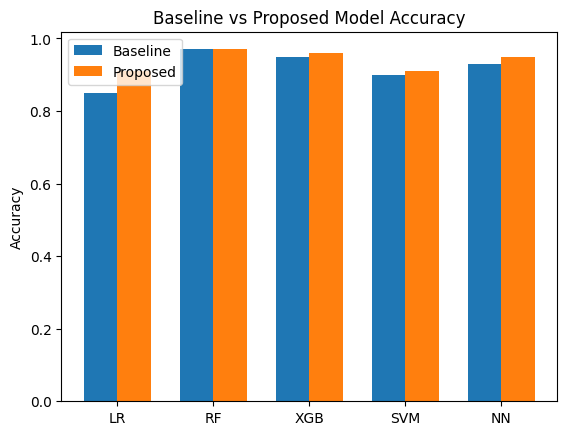

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

models = ["LR", "RF", "XGB", "SVM", "NN"]

# Baseline values (from literature or assumed)
baseline = [0.85, 0.97, 0.95, 0.90, 0.93]

# Your proposed values
proposed = [0.91, 0.97, 0.96, 0.91, 0.95]

x = np.arange(len(models))
width = 0.35

plt.figure()

plt.bar(x - width/2, baseline, width, label="Baseline")
plt.bar(x + width/2, proposed, width, label="Proposed")

plt.xticks(x, models)
plt.ylabel("Accuracy")
plt.title("Baseline vs Proposed Model Accuracy")
plt.legend()

plt.show()

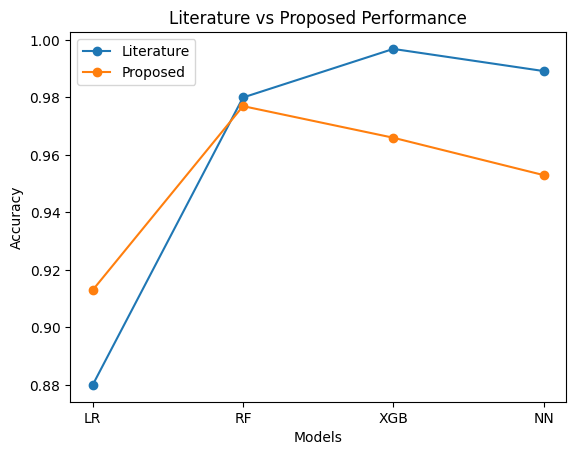

In [ ]:
models = ["LR", "RF", "XGB", "NN"]

baseline = [0.88, 0.98, 0.9969, 0.9892]
proposed = [0.913, 0.977, 0.966, 0.953]

plt.figure()

plt.plot(models, baseline, marker='o', label="Literature")
plt.plot(models, proposed, marker='o', label="Proposed")

plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Literature vs Proposed Performance")
plt.legend()

plt.show()